# Audio Feature Extraction using DSP

## Introduction

After preparing and standardizing the datasets, the next stage of the project is feature extraction.

Machine Learning and Deep Learning algorithms cannot directly operate on raw audio waveforms efficiently. Therefore, audio recordings must be transformed into structured numerical representations.

This notebook focuses on extracting meaningful information from music signals using Digital Signal Processing (DSP) techniques.

The objective is to convert audio recordings into representations that preserve musical characteristics while reducing dimensionality and improving learning efficiency.

The extracted features will later serve as inputs for:

- Classical Machine Learning models,
- Convolutional Neural Networks (CNN),
- and Transfer Learning experiments.

---

## Objectives

The main goals of this notebook are:

- apply the preprocessing pipeline to prepared datasets,
- transform audio signals into frequency-domain representations,
- extract informative audio descriptors,
- compare multiple feature extraction approaches,
- and generate reusable datasets for later model training.

---

## Planned Feature Extraction Steps

The following operations will be performed:

1. Load prepared metadata splits

2. Apply audio preprocessing
   - resampling
   - mono conversion
   - duration standardization

3. Generate Short-Time Fourier Transform (STFT)

4. Generate Mel Spectrogram representations

5. Extract Mel Frequency Cepstral Coefficients (MFCC)

6. Compare extracted feature representations

7. Save extracted features for later experiments

---

## DSP Motivation

Music contains information distributed across both:

- time,
- and frequency.

Waveforms describe signal amplitude over time but do not directly reveal spectral content.

Digital Signal Processing enables transformation of audio into representations that expose:

- rhythmic information,
- spectral energy distribution,
- harmonic structure,
- and timbral characteristics.

These representations are expected to improve genre discrimination.

---

## Expected Output

The output of this notebook will be numerical feature representations prepared for Machine Learning and Deep Learning models.

The next notebooks will focus on:

- Classical Machine Learning experiments,
- CNN training,
- MobileNetV2 transfer learning,
- and model optimization.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import librosa
import librosa.display


from src.utils.config import *

from src.data.preprocessing import (
    preprocess_audio
)

from src.data.feature_extraction import (
    compute_stft,
    compute_mel_spectrogram,
    compute_mfcc,
    aggregate_mfcc,
    extract_mfcc_dataset
)

In [2]:
train = pd.read_csv(
    GTZAN_TRAIN_PATH
)

validation = pd.read_csv(
    GTZAN_VALIDATION_PATH
)

external = pd.read_csv(
    FMA_EXTERNAL_PATH
)

print(
    "Train:",
    train.shape
)

print(
    "Validation:",
    validation.shape
)

print(
    "External:",
    external.shape
)

Train: (800, 4)
Validation: (200, 4)
External: (8745, 6)


# Load Prepared Metadata

Instead of reading raw datasets again, this notebook loads the prepared metadata generated during preprocessing.

This guarantees:

- reproducibility,
- separation between preprocessing and feature extraction,
- and identical experimental conditions across models.

In [3]:
train.head()

,dataset,filepath,original_genre,label
0,gtzan,C:\Softuni ML course\Project\music-genre-class...,jazz,jazz
1,gtzan,C:\Softuni ML course\Project\music-genre-class...,country,country
2,gtzan,C:\Softuni ML course\Project\music-genre-class...,rock,rock
3,gtzan,C:\Softuni ML course\Project\music-genre-class...,jazz,jazz
4,gtzan,C:\Softuni ML course\Project\music-genre-class...,jazz,jazz


In [4]:
EXAMPLE_GENRE = "jazz"

example = train[
    train["label"] == EXAMPLE_GENRE
].iloc[0]

filepath = example[
    "filepath"
]

label = example[
    "label"
]

print(
    "Genre:",
    label
)

y, sr = preprocess_audio(
    filepath,
    SAMPLE_RATE,
    MONO,
    TARGET_DURATION,
    CROP_MODE,
    NORMALIZATION
)

print(
    y.shape
)

Genre: jazz
(617400,)


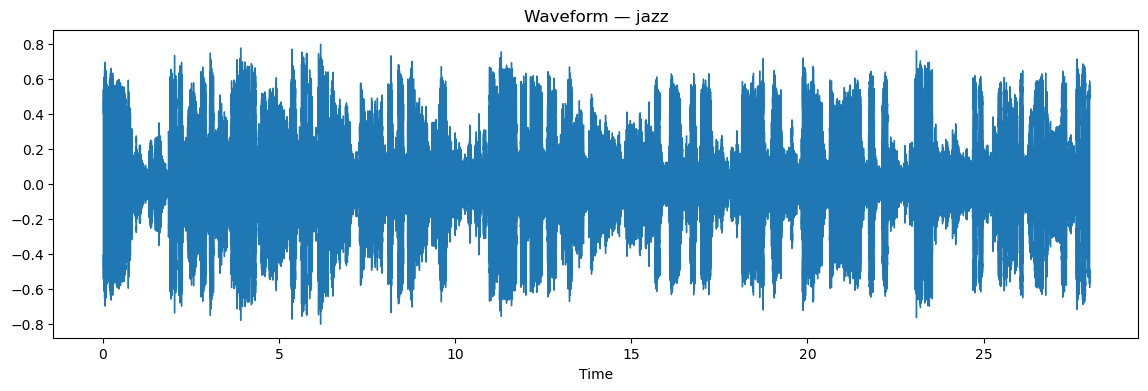

In [5]:
plt.figure(
    figsize=(14,4)
)

librosa.display.waveshow(
    y,
    sr=sr
)

plt.title(
    f"Waveform — {label}"
)

plt.show()

# Short-Time Fourier Transform (STFT)

The waveform representation shows amplitude over time but does not reveal spectral structure.

Short-Time Fourier Transform (STFT) extends the classical Fourier Transform by applying it over small overlapping windows.

This allows analysis of:

- frequency content,
- temporal changes,
- spectral dynamics,
- and energy distribution over time.

The result is a time-frequency representation where:

- horizontal axis → time,
- vertical axis → frequency,
- color intensity → signal energy.

In [6]:
# ================================
# Compute STFT
# ================================

stft = compute_stft(
    y
)

print(
    "STFT shape:"
)

print(
    stft.shape
)

STFT shape:
(1025, 1206)


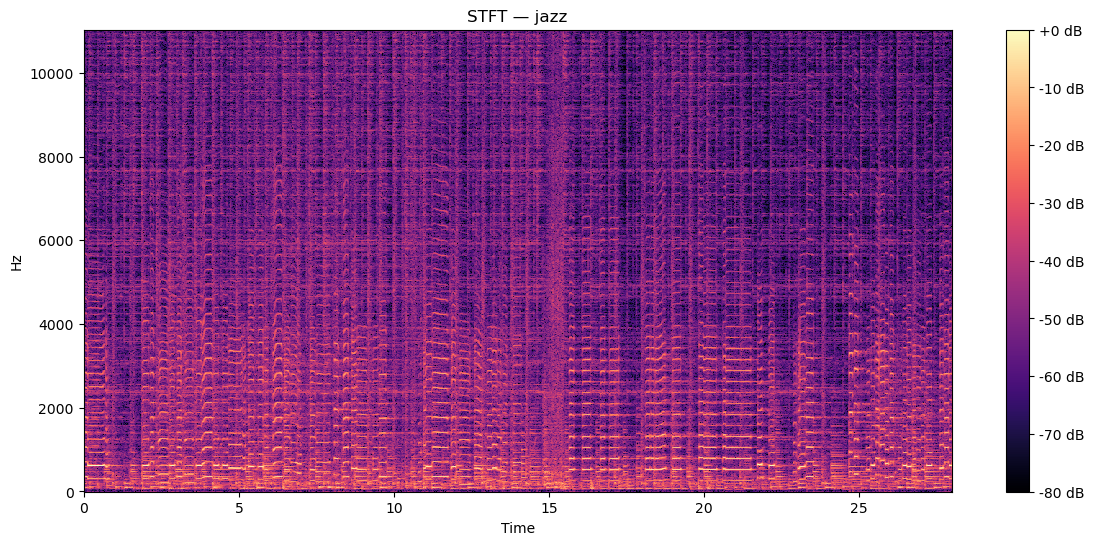

In [7]:
# ================================
# Visualize STFT
# ================================

plt.figure(
    figsize=(14,6)
)

librosa.display.specshow(

    stft,

    sr=sr,

    x_axis="time",

    y_axis="hz"

)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title(
    f"STFT — {label}"
)

plt.show()

# STFT Interpretation

The STFT representation of the selected jazz recording reveals how spectral energy evolves across time and frequency.

Several observations can be made:

- Most energy appears concentrated below approximately **3–4 kHz**, while higher frequencies contain weaker but still informative harmonic content.

- Multiple visible horizontal structures suggest the presence of sustained harmonic components, which are characteristic of pitched musical signals.

- Spectral density varies over time, indicating changing musical events and dynamic variation throughout the recording.

- Vertical transitions indicate temporal changes and note onsets that contribute to rhythmic structure.

- The absence of a constant high-energy band suggests that energy is distributed across multiple frequency regions rather than dominated by a single narrow component.

Overall, the STFT reveals a rich time-frequency structure that is difficult to observe directly from the waveform.

This motivates the use of more compact and perceptually motivated representations such as Mel Spectrograms and MFCC.

# Mel Spectrogram

Although STFT reveals detailed frequency information, human hearing does not perceive frequencies linearly.

The Mel scale approximates human pitch perception by allocating more resolution to lower frequencies and compressing higher frequencies.

A Mel Spectrogram transforms the STFT representation into a perceptually motivated frequency scale.

Compared to STFT:

- low frequencies receive greater detail,
- high frequencies become compressed,
- and overall structure becomes more suitable for machine learning.

Mel Spectrograms are commonly used for:

- music classification,
- speech recognition,
- audio tagging,
- and convolutional neural networks.

In [8]:
# ================================
# Compute Mel Spectrogram
# ================================

mel = compute_mel_spectrogram(
    y,
    sr
)

print(
    "Mel shape:"
)

print(
    mel.shape
)

Mel shape:
(128, 1206)


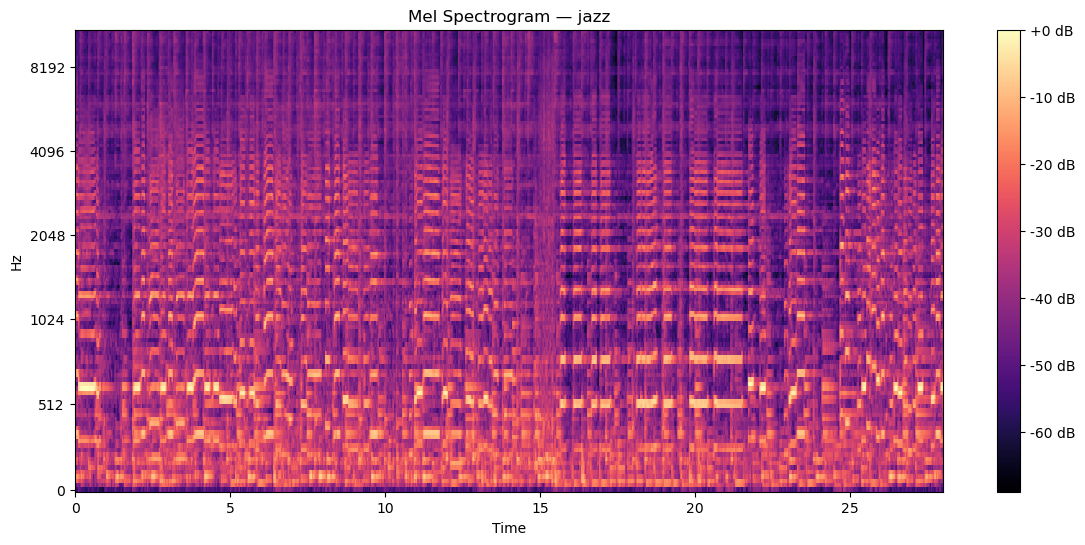

In [9]:
# ================================
# Visualize Mel Spectrogram
# ================================

plt.figure(
    figsize=(14,6)
)

librosa.display.specshow(

    mel,

    sr=sr,

    x_axis="time",

    y_axis="mel"

)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title(
    f"Mel Spectrogram — {label}"
)

plt.show()

# Mel Spectrogram Interpretation

Compared to STFT, the Mel Spectrogram compresses the frequency axis and allocates more resolution to lower frequencies.

In this example:

- energy is concentrated in lower Mel regions,
- harmonic structures remain visible,
- temporal changes remain preserved,
- and high-frequency details become compressed.

This representation better approximates human auditory perception and is therefore widely used for music classification and Deep Learning.

# MFCC Extraction

MFCCs compress spectral information into a smaller set of coefficients.

While Mel Spectrograms preserve detailed time-frequency information, MFCCs summarize the spectral envelope of the sound.

This makes MFCCs especially useful for classical Machine Learning models, where compact feature vectors are often preferred.

In [10]:
# ================================
# Compute MFCC
# ================================

mfcc = compute_mfcc(
    y,
    sr
)

print(
    "MFCC shape:"
)

print(
    mfcc.shape
)

MFCC shape:
(20, 1206)


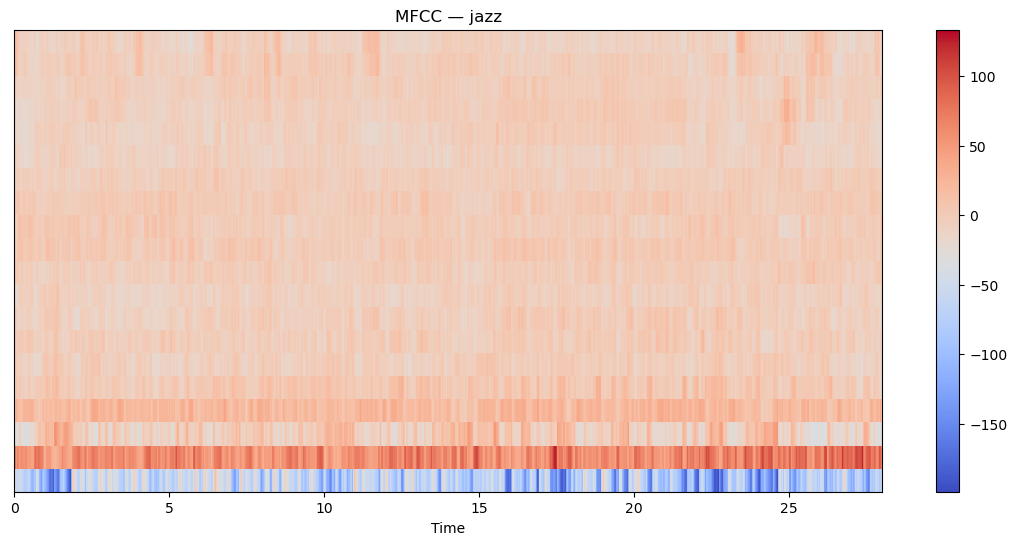

In [11]:
# ================================
# Visualize MFCC
# ================================

plt.figure(
    figsize=(14,6)
)

librosa.display.specshow(
    mfcc,
    sr=sr,
    x_axis="time"
)

plt.colorbar()

plt.title(
    f"MFCC — {label}"
)

plt.show()

# MFCC Interpretation

The MFCC representation compresses the spectral information of the audio signal into a smaller number of coefficients.

In this example, the MFCC matrix has shape **20 × 1206**, meaning:

- 20 cepstral coefficients,
- 1206 time frames.

Compared to the Mel Spectrogram, MFCC keeps the temporal structure but strongly reduces the frequency-related dimensionality.

Several observations can be made:

- lower-order coefficients contain the most prominent spectral envelope information,
- higher-order coefficients capture finer spectral variations,
- the representation is significantly more compact than the Mel Spectrogram.

This makes MFCC suitable for classical Machine Learning models such as SVM and Random Forest.

In later experiments, MFCC statistics will be converted into fixed-length feature vectors by computing summary statistics such as mean and standard deviation over time.

 # MFCC Feature Aggregation

Although MFCC preserves temporal information, classical Machine Learning algorithms usually require fixed-length feature vectors.

To transform variable-length time representations into compact numerical inputs, summary statistics are computed across time.

For each MFCC coefficient:

- mean value is calculated,
- standard deviation is calculated.

This produces a compact descriptor that summarizes the spectral behavior of the entire recording.

These vectors will later be used for:

- SVM,
- Random Forest,
- and other classical Machine Learning models.

In [12]:
# ================================
# Aggregate MFCC Features
# ================================

mfcc_mean = np.mean(
    mfcc,
    axis=1
)

mfcc_std = np.std(
    mfcc,
    axis=1
)

mfcc_vector = np.concatenate(

    [

        mfcc_mean,

        mfcc_std

    ]

)

print(
    "MFCC vector shape:"
)

print(
    mfcc_vector.shape
)

MFCC vector shape:
(40,)


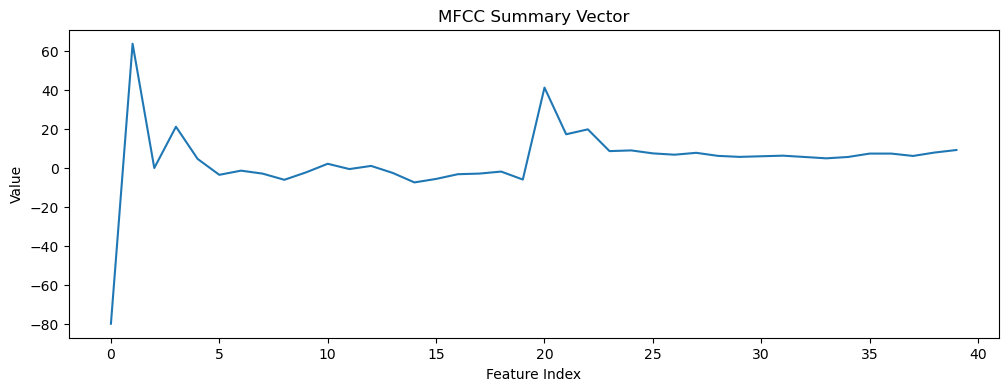

In [13]:
# ================================
# Visualize MFCC Summary
# ================================

plt.figure(
    figsize=(12,4)
)

plt.plot(
    mfcc_vector
)

plt.title(
    "MFCC Summary Vector"
)

plt.xlabel(
    "Feature Index"
)

plt.ylabel(
    "Value"
)

plt.show()

# MFCC Feature Vector Interpretation

The MFCC representation was reduced from a time-dependent matrix into a compact summary vector.

The resulting vector contains:

- first 20 values → mean MFCC coefficients,
- last 20 values → standard deviation of each coefficient.

Several observations can be made:

- lower-index coefficients exhibit larger variation because they capture the dominant spectral envelope,

- higher-index coefficients appear more stable and represent finer spectral details,

- the aggregated representation is significantly smaller than the original Mel Spectrogram.

This transformation converts the original audio signal into a fixed-length descriptor.

Such vectors are computationally efficient and suitable for classical Machine Learning algorithms.

The next stage will apply the same extraction procedure to the complete training dataset.

# Batch Feature Extraction

After validating the extraction pipeline on a single example, the same procedure is now applied to the complete dataset.

The objective is to generate reusable numerical representations that will later serve as direct inputs for Machine Learning and Deep Learning experiments.

Feature extraction is performed once and saved to disk to avoid repeated audio processing in later notebooks.

In [18]:
# ================================
# Extract MFCC Dataset
# ================================

mfcc_train = extract_mfcc_dataset(

    train,

    preprocess_audio,

    SAMPLE_RATE,

    MONO,

    TARGET_DURATION,

    CROP_MODE,

    NORMALIZATION
)

print(
    mfcc_train.shape
)

(800, 41)


In [19]:
mfcc_train.head()

,label,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,mfcc_30,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39
0,jazz,-79.918610,63.568348,-0.128822,21.026081,4.527999,-3.615189,-1.478588,-3.003456,-6.162390,...,5.897816,6.199116,5.527303,4.837486,5.530196,7.270189,7.269506,6.056642,7.814990,9.100511
1,country,-20.483147,62.888767,2.235743,30.451435,7.101816,6.934251,6.490396,10.380758,3.803166,...,7.142484,6.376490,6.529832,6.117419,5.774475,6.169862,6.703815,7.023354,5.847367,6.651565
2,rock,-117.750114,104.901207,-29.539276,42.494114,-13.537786,28.847147,-21.119274,21.888298,-24.459267,...,7.417220,6.776543,6.631548,6.557282,7.689167,6.571660,6.415704,7.009959,5.744596,5.793769
3,jazz,-292.307220,194.409073,8.028879,-1.858701,3.982460,9.764820,-7.701866,4.376356,-5.247402,...,7.299273,10.077146,8.728131,7.296290,6.458878,7.056380,7.525840,6.323605,7.183577,7.554375
4,jazz,-263.476379,176.641037,-42.731876,25.459568,-3.975781,-0.678765,-11.169247,-8.921755,-4.403948,...,10.156604,8.451771,7.717158,9.116176,7.977155,6.098691,7.461779,6.842474,6.599862,8.717117


In [20]:
mfcc_train.to_csv(
    MFCC_TRAIN_PATH,
    index=False
)

print(
    MFCC_TRAIN_PATH
)

C:\Softuni ML course\Project\music-genre-classification\data\processed\mfcc\mfcc_train.csv


In [21]:
pd.read_csv(
    MFCC_TRAIN_PATH
).head()

,label,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,mfcc_30,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39
0,jazz,-79.918610,63.568348,-0.128822,21.026081,4.527999,-3.615189,-1.478588,-3.003456,-6.162390,...,5.897816,6.199116,5.527303,4.837486,5.530196,7.270189,7.269506,6.056642,7.814990,9.100511
1,country,-20.483147,62.888767,2.235743,30.451435,7.101816,6.934251,6.490397,10.380758,3.803166,...,7.142484,6.376490,6.529832,6.117419,5.774475,6.169862,6.703816,7.023354,5.847367,6.651565
2,rock,-117.750114,104.901210,-29.539276,42.494114,-13.537786,28.847147,-21.119274,21.888298,-24.459267,...,7.417220,6.776543,6.631548,6.557282,7.689166,6.571660,6.415704,7.009959,5.744597,5.793769
3,jazz,-292.307220,194.409070,8.028879,-1.858701,3.982460,9.764820,-7.701866,4.376356,-5.247402,...,7.299273,10.077146,8.728131,7.296290,6.458878,7.056380,7.525840,6.323605,7.183577,7.554375
4,jazz,-263.476380,176.641040,-42.731876,25.459568,-3.975781,-0.678765,-11.169247,-8.921755,-4.403948,...,10.156604,8.451771,7.717158,9.116176,7.977155,6.098691,7.461779,6.842474,6.599862,8.717117


# Saved Features

The extracted MFCC feature vectors are stored for later reuse.

Future notebooks will load the generated feature tables directly instead of reprocessing raw audio recordings.

# Validation MFCC Feature Extraction

The same MFCC extraction pipeline is applied to the validation split.

This ensures that training and validation data are represented using identical preprocessing and feature extraction settings.

In [22]:
# ================================
# Extract Validation MFCC Dataset
# ================================

mfcc_validation = extract_mfcc_dataset(
    validation,
    preprocess_audio,
    SAMPLE_RATE,
    MONO,
    TARGET_DURATION,
    CROP_MODE,
    NORMALIZATION
)

print(
    mfcc_validation.shape
)

(200, 41)


In [23]:
mfcc_validation.to_csv(
    MFCC_VALIDATION_PATH,
    index=False
)

print(
    MFCC_VALIDATION_PATH
)

C:\Softuni ML course\Project\music-genre-classification\data\processed\mfcc\mfcc_validation.csv


In [24]:
pd.read_csv(
    MFCC_VALIDATION_PATH
).head()

,label,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,mfcc_30,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39
0,classical,-265.20078,136.270920,-25.286210,26.968348,0.074161,-5.335724,-1.422405,-1.525670,-0.077466,...,9.175609,9.938628,9.953010,11.074131,10.750846,9.490089,9.092187,7.813792,9.615143,13.051168
1,blues,-334.45370,128.336850,30.585043,42.611713,31.422487,24.077276,5.593525,8.135833,-3.340539,...,9.515923,8.582698,9.021724,8.141394,7.393994,7.354432,8.352892,6.466018,6.733354,5.624948
2,metal,-198.49680,73.973206,-10.935589,54.625977,-7.464795,18.464622,-18.790840,11.437551,-14.763203,...,8.423779,8.052206,8.186366,9.159916,7.401631,7.936935,9.320035,9.416060,8.543408,7.255552
3,jazz,-260.34976,182.467160,-17.791843,50.220886,-1.038162,6.306088,5.786904,-8.862904,-10.406028,...,7.176178,5.733652,6.285619,6.240463,5.431449,6.613965,6.074832,8.108317,6.533389,7.538397
4,blues,-261.70600,137.819320,9.592551,49.222720,14.241323,20.177362,2.913063,1.157265,-16.188820,...,9.085856,8.373226,8.436867,8.469395,9.306089,9.726425,9.915272,11.150331,11.037846,12.393329


# External Dataset Policy

The external FMA Medium dataset is intentionally excluded from feature extraction at this stage.

Although feature extraction itself does not perform model learning, generating and inspecting transformed representations may unintentionally influence later design decisions.

To preserve the idea of external evaluation, the FMA dataset will remain untouched during development.

Feature extraction for FMA Medium will be performed only during the final evaluation notebook.

This approach ensures:

- separation between development and testing,
- prevention of accidental information leakage,
- and a more realistic estimate of generalization performance.

# Conclusion

This notebook transformed preprocessed audio recordings into reusable numerical representations suitable for Machine Learning and Deep Learning.

The following stages were completed:

- loading prepared metadata splits,
- applying standardized audio preprocessing,
- generating STFT representations,
- generating Mel Spectrogram representations,
- extracting MFCC representations,
- converting MFCC into fixed-length feature vectors,
- and saving extracted features for later reuse.

Several observations were made:

- audio information is distributed across both time and frequency,
- perceptual representations reduce complexity while preserving musical information,
- and compact feature vectors enable efficient model training.

The generated feature datasets will serve as direct inputs for later experiments.

The next notebook will focus on:

- Classical Machine Learning models,
- feature scaling,
- model selection,
- and evaluation on the validation dataset.